# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.


In [8]:
%%html
<link rel="stylesheet" href="./style.css">

In [9]:
import import_ipynb  # noqa: F401
from treatment import f_df, f_numeric_columns  # type: ignore


In [10]:
import matplotlib.pyplot as plt
from kmodes.kprototypes import KPrototypes
from sklearn.decomposition import PCA

from columns import categorical_columns

# Identify indexes of categorical indexes
indexes_of_categorical_columns = [
    f_df.columns.get_loc(col) for col in categorical_columns
]

In [11]:
clustered_df_through_kp = f_df.copy()

k_prototypes_protocol = KPrototypes(n_clusters=4, random_state=42)

clusters = k_prototypes_protocol.fit_predict(
    clustered_df_through_kp, categorical=indexes_of_categorical_columns
)

# Add column describing the cluster to the database
clustered_df_through_kp["Cluster"] = clusters


Número de clusters: 4
Número de variáveis: 21

Centróides:
[['-1.4380311765388532' '0.008418327442745973' '-0.05230093722705379'
  '-0.017412516134006725' '-0.015841349792165317' '0.017007993410353563'
  '144.15506958250498' '9198.55069582505' '0.004958980822583772'
  '-0.047332215186696044' '-0.014757503524586695' '-0.019431139592378317'
  '0.011823030776939428' 'Sankarapuram' 'ponmani' 'clay' 'dry' 'SSE' 'W'
  'SE' 'NW']
 ['1.039742648704831' '-0.020135600366330837' '0.027969545814542682'
  '-0.017144910200918455' '0.018607245662906193' '-0.012032005615209231'
  '466.078431372549' '32125.83790849673' '-0.005585307476209022'
  '0.014070839997298228' '0.011224886619921765' '0.023043526354185426'
  '-0.006660096551925921' 'Sankarapuram' 'delux ponni' 'clay' 'dry' 'SSE'
  'W' 'SE' 'NW']
 ['0.22615311786195932' '0.021060001702794956' '-0.00383068725857077'
  '0.025845924005666862' '-0.019557126495094976' '-0.013239731530177993'
  '362.2246696035242' '24508.12334801762' '0.0168568817575709

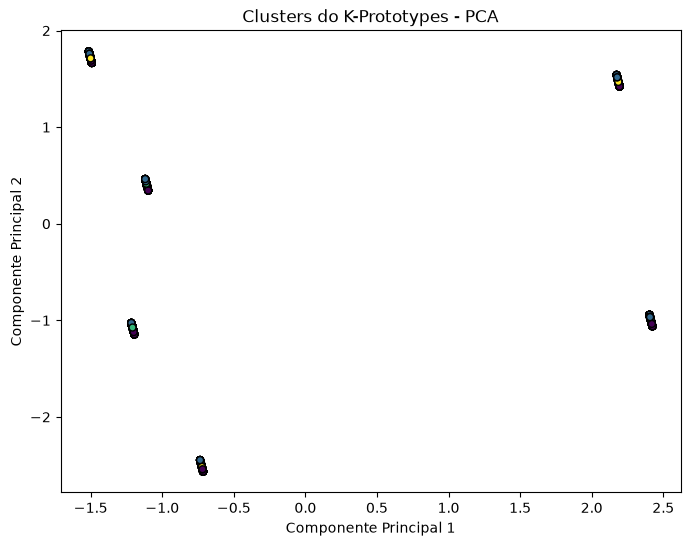

In [ ]:
centroides = k_prototypes_protocol.cluster_centroids_

print("Número de clusters:", k_prototypes_protocol.n_clusters)
print("Número de variáveis:", len(clustered_df_through_kp.columns) - 1)

print("\nCentroides:")
print(centroides)


pca = PCA(n_components=2)

xn = pca.fit_transform(clustered_df_through_kp[f_numeric_columns])
plt.figure(figsize=(8, 6))

plt.scatter(xn[:, 0], xn[:, 1], marker="o", c=clusters, s=25, edgecolor="k")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters do K-Prototypes - PCA")

plt.show()